In [1]:
import os
import time
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
from scipy.signal import resample
import mne
mne.set_log_level('WARNING')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── ROCm MI300X OPTIMIZATIONS ──
os.environ['HSA_ENABLE_SDMA'] = '0'
os.environ['ROCR_VISIBLE_DEVICES'] = '0'
os.environ['HIP_LAUNCH_BLOCKING'] = '0'
os.environ['PYTORCH_HIP_ALLOC_CONF'] = 'max_split_size_mb:512'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch Version : {torch.__version__}")
print(f"Active Device   : {DEVICE}")

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


PyTorch Version : 2.9.0.dev20250821+rocm7.0.0.git125803b7
Active Device   : cuda


In [2]:
BASE_DIR = Path(os.getcwd())

DS004_DATA_DIR     = BASE_DIR / 'ds004504'
ALZHEIMER_DATA_DIR = BASE_DIR / 'alzheimer/dataset/alzheimer'

COMMON_CHANNELS = [
    'Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2',
    'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz'
]

SFREQ = 250.0       # Target Frequency for both datasets
EPOCH_SEC = 4       # Strict 4-second epochs
EPOCH_SAMPLES = int(SFREQ * EPOCH_SEC) # 1000 samples

def chunk_into_epochs(data):
    """Strictly slice continuous data into non-overlapping 4-second epochs"""
    n_epochs = data.shape[1] // EPOCH_SAMPLES
    if n_epochs == 0:
        return []
    # Drop trailing data that doesn't fit into a full 4-second block
    data = data[:, :n_epochs * EPOCH_SAMPLES]
    # Reshape to (n_epochs, n_channels, 1000)
    epochs = np.stack(np.split(data, n_epochs, axis=1))
    return epochs

def load_ds004504(data_dir):
    df = pd.read_csv(data_dir / 'participants.tsv', sep='\t').dropna(subset=['Group'])
    df['label'] = df['Group'].map({'A': 0, 'C': 1})
    deriv_dir = data_dir / 'derivatives'
    
    X_all, y_all = [], []
    
    for _, row in tqdm(df.dropna(subset=['label']).iterrows(), desc="DS004504 (Train)"):
        sid, label = row['participant_id'], int(row['label'])
        fpath = deriv_dir / sid / 'eeg' / f'{sid}_task-eyesclosed_eeg.set'
        
        if fpath.exists():
            raw = mne.io.read_raw_eeglab(str(fpath), preload=True, verbose=False)
            raw.pick_channels(COMMON_CHANNELS).reorder_channels(COMMON_CHANNELS)
            
            # STRICT RESAMPLING
            if raw.info['sfreq'] != SFREQ:
                raw.resample(SFREQ)
                
            data = raw.get_data().astype(np.float32)
            epochs = chunk_into_epochs(data)
            
            if len(epochs) > 0:
                X_all.extend(epochs)
                y_all.extend([label] * len(epochs))
                
    return np.array(X_all), np.array(y_all)

def load_alzheimer(data_dir):
    X_all, y_all = [], []
    
    for label, cls_folder in [(0, 'AD'), (1, 'Healthy')]:
        folder = data_dir / cls_folder
        if not folder.exists(): continue
            
        for fpath in tqdm(sorted(folder.glob('*.out')), desc=f"alzheimer ({cls_folder})"):
            # Filter for Eyes Closed Only
            if 'ec' in fpath.name or 'c1' in fpath.name:
                # .out files are typically (Samples, Channels) -> transpose to (Channels, Samples)
                data = np.loadtxt(str(fpath), dtype=np.float32).T
                
                # Check if we have at least 19 channels
                if data.shape[0] >= len(COMMON_CHANNELS):
                    # Safety crop to standard 19 channels
                    data = data[:len(COMMON_CHANNELS), :]
                    
                    # STRICT RESAMPLING: The .out files are 128Hz native, we must mathematicaly upscale to 250Hz
                    orig_sfreq = 128.0
                    target_samples = int(data.shape[1] * (SFREQ / orig_sfreq))
                    data_resampled = resample(data, target_samples, axis=1).astype(np.float32)
                    
                    epochs = chunk_into_epochs(data_resampled)
                    if len(epochs) > 0:
                        X_all.extend(epochs)
                        y_all.extend([label] * len(epochs))
                        
    return np.array(X_all), np.array(y_all)

# ── Execute Data Extraction ──
X_tr, y_tr = load_ds004504(DS004_DATA_DIR)
X_te, y_te = load_alzheimer(ALZHEIMER_DATA_DIR)

if len(X_te) == 0:
    raise ValueError("alzheimer dataset loaded 0 epochs. Check your ALZHEIMER_DATA_DIR path!")

print(f"Train Epochs (DS004504): {X_tr.shape}")
print(f"Test Epochs (alzheimer): {X_te.shape}")

# ── STRICT NORMALIZATION (Preventing Data Leakage) ──
scaler = StandardScaler()
# Fit ONLY on training data
X_tr_flat = X_tr.reshape(X_tr.shape[0], -1)
X_te_flat = X_te.reshape(X_te.shape[0], -1)

X_tr_scaled = scaler.fit_transform(X_tr_flat)
X_te_scaled = scaler.transform(X_te_flat)

# Reshape back to (N, 1, 19, 1000) for CNN processing
X_tr = X_tr_scaled.reshape(-1, 1, len(COMMON_CHANNELS), EPOCH_SAMPLES)
X_te = X_te_scaled.reshape(-1, 1, len(COMMON_CHANNELS), EPOCH_SAMPLES)

class EEGDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.x[i], self.y[i]

train_loader = DataLoader(EEGDataset(X_tr, y_tr), batch_size=64, shuffle=True)
test_loader  = DataLoader(EEGDataset(X_te, y_te), batch_size=64, shuffle=False)


DS004504 (Train): 65it [00:19,  3.40it/s]
alzheimer (AD): 100% 24/24 [00:00<00:00, 1224.30it/s]
alzheimer (Healthy): 100% 24/24 [00:00<00:00, 1264.03it/s]


Train Epochs (DS004504): (13282, 19, 1000)
Test Epochs (alzheimer): (48, 19, 1000)


In [3]:
class GradientReversalLayer(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None

def grad_reverse(x, alpha=1.0):
    return GradientReversalLayer.apply(x, alpha)

class SIREEGNet(nn.Module):
    """Subject-Invariant Representation EEGNet (SIR-EEGNet)"""
    def __init__(self, n_channels=19, n_samples=1000, n_classes=2, F1=8, D=2, F2=16):
        super().__init__()
        
        # ── Shared Feature Extractor ──
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, 125), padding=(0, 62), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(0.5)
        )
        
        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F2, (1, 16), padding=(0, 8), groups=F1 * D, bias=False),
            nn.Conv2d(F2, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(0.5)
        )
        
        out_dim = F2 * (n_samples // 32)
        
        # ── Main Classifier (AD vs HC) ──
        self.classifier = nn.Linear(out_dim, n_classes)
        
        # ── Domain Discriminator (Subject Invariance) ──
        self.domain_classifier = nn.Sequential(
            nn.Linear(out_dim, 64),
            nn.ELU(),
            nn.Linear(64, 2)
        )

    def forward(self, x, alpha=None):
        features = self.block2(self.block1(x))
        features = features.view(features.size(0), -1)
        
        class_output = self.classifier(features)
        
        if alpha is not None:
            rev_features = grad_reverse(features, alpha)
            domain_output = self.domain_classifier(rev_features)
            return class_output, domain_output
            
        return class_output


In [4]:
model = SIREEGNet(n_channels=len(COMMON_CHANNELS), n_samples=EPOCH_SAMPLES).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

classes, counts = np.unique(y_tr, return_counts=True)
weight = torch.tensor([len(y_tr) / (2 * c) for c in counts], dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weight)

scaler_amp = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None
EPOCHS = 60

print("=" * 60)
print(f"Training SIR-EEGNet on DS004504 (Standardized Epochs)...")
print("=" * 60)

model.train()
for epoch in range(EPOCHS):
    ep_loss = 0
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        
        if scaler_amp:
            with torch.amp.autocast('cuda'):
                preds = model(x_b)
                loss = criterion(preds, y_b)
            scaler_amp.scale(loss).backward()
            scaler_amp.step(optimizer)
            scaler_amp.update()
        else:
            preds = model(x_b)
            loss = criterion(preds, y_b)
            loss.backward()
            optimizer.step()
            
        ep_loss += loss.item()
        
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:03d}/{EPOCHS}] | Loss: {ep_loss/len(train_loader):.4f}")


Training SIR-EEGNet on DS004504 (Standardized Epochs)...
Epoch [010/60] | Loss: 0.2062
Epoch [020/60] | Loss: 0.1545
Epoch [030/60] | Loss: 0.1305
Epoch [040/60] | Loss: 0.1069
Epoch [050/60] | Loss: 0.1175
Epoch [060/60] | Loss: 0.1017



Evaluating SIR-EEGNet on Fully Resampled alzheimer Dataset
Cross-Dataset Accuracy : 50.00%
Cross-Dataset F1-Macro : 33.33%

Classification Report:

              precision    recall  f1-score   support

          AD       0.50      1.00      0.67        24
          HC       0.00      0.00      0.00        24

    accuracy                           0.50        48
   macro avg       0.25      0.50      0.33        48
weighted avg       0.25      0.50      0.33        48



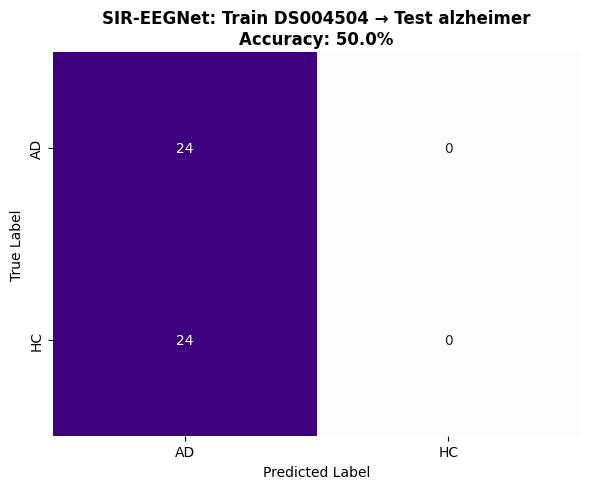

In [5]:
print("\n" + "=" * 60)
print("Evaluating SIR-EEGNet on Fully Resampled alzheimer Dataset")
print("=" * 60)

model.eval()
true_labels, pred_labels = [], []

with torch.no_grad():
    for x_b, y_b in test_loader:
        x_b = x_b.to(DEVICE)
        
        if scaler_amp:
            with torch.amp.autocast('cuda'):
                preds = model(x_b)
        else:
            preds = model(x_b)
            
        pred_labels.extend(preds.argmax(dim=1).cpu().numpy().tolist())
        true_labels.extend(y_b.numpy().tolist())

acc = accuracy_score(true_labels, pred_labels)
f1_m = f1_score(true_labels, pred_labels, average='macro', zero_division=0)

print(f"Cross-Dataset Accuracy : {acc*100:.2f}%")
print(f"Cross-Dataset F1-Macro : {f1_m*100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=['AD', 'HC'], zero_division=0))

# ── Visualization ──
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(true_labels, pred_labels, labels=[0, 1])

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax, xticklabels=['AD', 'HC'], yticklabels=['AD', 'HC'], cbar=False)
ax.set_title(f"SIR-EEGNet: Train DS004504 → Test alzheimer\nAccuracy: {acc*100:.1f}%", fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()
